## Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Import the Dataset

In [2]:
df = pd.read_csv("startup_success_dataset.csv")

print(df.shape)

df.head()

(100000, 11)


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.225483,594843,18.519211,1.483962e+06,tier2_vc,Health,academic,IPO
1,1,6,221,31.532647,393020,14.298149,8.620568e+05,tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.969722,27636,20.447567,9.726169e+04,none,SaaS,first_time,Failure
3,3,14,229,3.084209,235376,8.177417,1.145785e+06,none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.818188,391765,4.879792,8.608949e+05,none,Health,first_time,Acquisition


## View the Dataset

In [3]:
df.columns

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05
mean,2.002300,12.024300,150.732000,33.203875,285422.832730,16.776213,7.828191e+05
std,1.414671,7.208089,86.272631,43.034753,159323.885405,15.711368,6.085069e+05
min,0.000000,0.000000,2.000000,0.288738,668.000000,0.279763,1.344810e+03
25%,1.000000,6.000000,76.000000,10.196778,161194.750000,7.087591,3.154861e+05
50%,2.000000,12.000000,151.000000,20.158063,264989.500000,12.169059,6.213624e+05
75%,3.000000,18.000000,226.000000,39.531967,389214.000000,20.953561,1.098921e+06
max,8.000000,24.000000,299.000000,1072.434476,915203.000000,357.491454,4.168443e+06


## Data Cleaning

In [4]:
df = df.dropna()

df = df.fillna(df.mean(numeric_only=True))


## Creating Target Variable

In [5]:
df['success'] = df['outcome'].apply(
    lambda x: 1 if x in ['IPO','Acquisition'] else 0
)

df['success'].value_counts()

success
0    55610
1    44390
Name: count, dtype: int64

## Handling Imbalanced Data

In [6]:
from sklearn.utils import resample

success_df = df[df.success == 1]

failure_df = df[df.success == 0]

failure_downsampled = resample(

    failure_df,

    replace=False,

    n_samples=len(success_df),

    random_state=42
)

balanced_df = pd.concat([

    success_df,

    failure_downsampled

])

balanced_df['success'].value_counts()

success
1    44390
0    44390
Name: count, dtype: int64

## Feature Selection and Encoding

In [7]:
features = [

'funding_rounds',

'founder_experience_years',

'team_size',

'market_size_billion',

'product_traction_users',

'burn_rate_million',

'revenue_million'

]

X = balanced_df[features]

X = pd.get_dummies(

    X.join(

        balanced_df[

            ['investor_type','sector','founder_background']

        ]

    )

)

y = balanced_df['success']

## Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

## Model Training

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(

    n_estimators=300,

    max_depth=10,

    random_state=42

)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## Model Evaluation (Accuracy)

In [10]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.749831043027709


## Confusion Matrix and Classification Report

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[6784 2015]
 [2427 6530]]
              precision    recall  f1-score   support

           0       0.74      0.77      0.75      8799
           1       0.76      0.73      0.75      8957

    accuracy                           0.75     17756
   macro avg       0.75      0.75      0.75     17756
weighted avg       0.75      0.75      0.75     17756



## Data Visualization

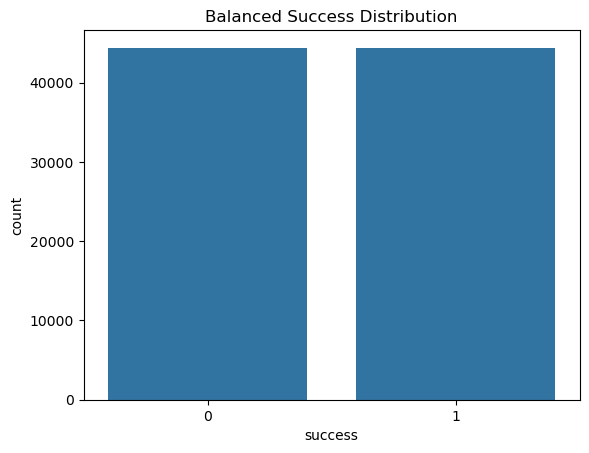

In [12]:
sns.countplot(

    x='success',

    data=balanced_df

)

plt.title("Balanced Success Distribution")

plt.show()

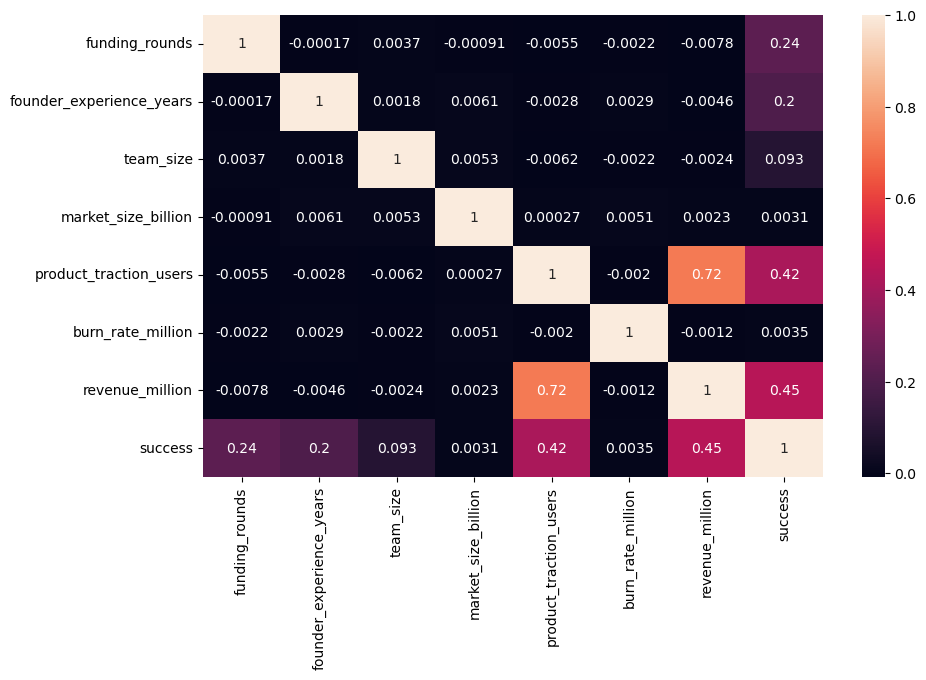

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(

    balanced_df.corr(numeric_only=True),

    annot=True

)

plt.show()

## Feature Importance Analysis

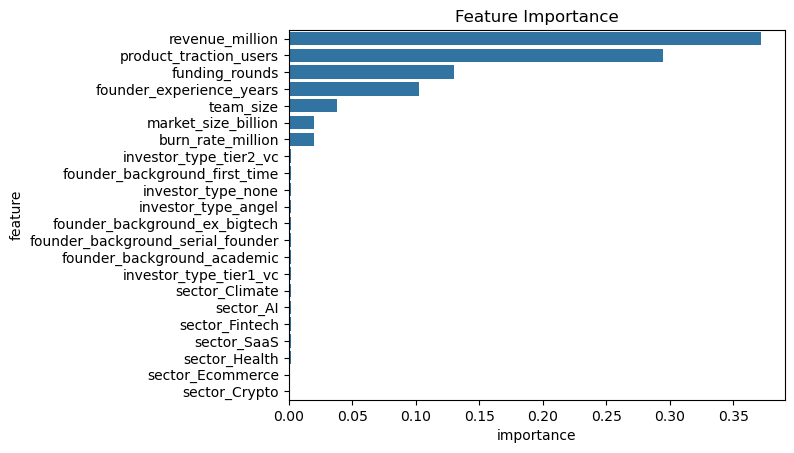

In [14]:
importance_df = pd.DataFrame({

'feature': X.columns,

'importance': model.feature_importances_

})

importance_df = importance_df.sort_values(

    'importance',

    ascending=False

)

sns.barplot(

    x='importance',

    y='feature',

    data=importance_df

)

plt.title("Feature Importance")

plt.show()

## Prediction on New Data

In [15]:
new_data = pd.DataFrame({

'funding_rounds':[6],

'founder_experience_years':[12],

'team_size':[40],

'market_size_billion':[25],

'product_traction_users':[800000],

'burn_rate_million':[2],

'revenue_million':[18],

'investor_type':['VC'],

'sector':['AI'],

'founder_background':['Technical']

})

new_data = pd.get_dummies(new_data)

new_data = new_data.reindex(

    columns=X.columns,

    fill_value=0

)

prediction = model.predict(new_data)

probability = model.predict_proba(new_data)

print("Prediction:", prediction)

print("Success probability:", probability)

Prediction: [1]
Success probability: [[0.38762147 0.61237853]]


## Saving the Model

In [16]:
import pickle

pickle.dump(

    model,

    open("model.pkl","wb")

)

pickle.dump(

    X.columns,

    open("model_columns.pkl","wb")

)

print("Model saved successfully")

Model saved successfully
